# LeetCode #113: Path Sum II

https://leetcode.com/problems/path-sum-ii/

## Comparison of Approaches

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| BFS with path per node | O(n²) | O(n²) | Full path copied at each node — expensive |
| **DFS Backtracking ★** | **O(n²)** | **O(n)** | Single shared path, backtrack after each call |

---

## Understanding the Methods

### BFS with Full Paths
Queue stores (node, current_path). At each leaf, add path to result if sum matches. O(n²) time and space due to path copies.

### DFS Backtracking (Optimal ★)
The classic backtracking pattern: push → recurse → pop. A single `current` list is reused for all paths. At each leaf where rem==0, copy `current` to result. After recursion, pop the last element to restore the path. Space = O(h) for path + O(total path length) for result.

## Constraints
- Number of nodes: [0, 5000]
- Node values: [-1000, 1000]
- targetSum: [-1000, 1000]

## Solutions

### C#

In [ ]:
public class Solution {
    private IList<IList<int>> result = new List<IList<int>>();
    private List<int> path = new List<int>();

    public IList<IList<int>> PathSum(TreeNode root, int targetSum) {
        Dfs(root, targetSum);
        return result;
    }

    private void Dfs(TreeNode node, int rem) {
        if (node == null) return;
        rem -= node.val;
        path.Add(node.val);
        if (node.left == null && node.right == null && rem == 0)
            result.Add(new List<int>(path));
        Dfs(node.left,  rem);
        Dfs(node.right, rem);
        path.RemoveAt(path.Count - 1);  // backtrack
    }
}

### Python

In [ ]:
class Solution:
    def pathSum(self, root, targetSum: int) -> list[list[int]]:
        result, path = [], []

        def dfs(node, rem):
            if not node: return
            rem -= node.val
            path.append(node.val)
            if not node.left and not node.right and rem == 0:
                result.append(list(path))
            dfs(node.left,  rem)
            dfs(node.right, rem)
            path.pop()  # backtrack

        dfs(root, targetSum)
        return result

### Go

In [ ]:
func pathSum(root *TreeNode, targetSum int) [][]int {
    result := [][]int{}
    path   := []int{}

    var dfs func(node *TreeNode, rem int)
    dfs = func(node *TreeNode, rem int) {
        if node == nil { return }
        rem -= node.Val
        path = append(path, node.Val)
        if node.Left == nil && node.Right == nil && rem == 0 {
            cp := make([]int, len(path))
            copy(cp, path)
            result = append(result, cp)
        }
        dfs(node.Left,  rem)
        dfs(node.Right, rem)
        path = path[:len(path)-1]  // backtrack
    }
    dfs(root, targetSum)
    return result
}

### Rust

In [ ]:
use std::rc::Rc;
use std::cell::RefCell;

impl Solution {
    pub fn path_sum(root: Option<Rc<RefCell<TreeNode>>>, target_sum: i32) -> Vec<Vec<i32>> {
        let mut result = vec![];
        let mut path   = vec![];
        Self::dfs(&root, target_sum, &mut path, &mut result);
        result
    }

    fn dfs(
        node:   &Option<Rc<RefCell<TreeNode>>>,
        rem:    i32,
        path:   &mut Vec<i32>,
        result: &mut Vec<Vec<i32>>,
    ) {
        let Some(n) = node else { return; };
        let val  = n.borrow().val;
        let rem  = rem - val;
        path.push(val);
        let left  = n.borrow().left.clone();
        let right = n.borrow().right.clone();
        if left.is_none() && right.is_none() && rem == 0 {
            result.push(path.clone());
        }
        Self::dfs(&left,  rem, path, result);
        Self::dfs(&right, rem, path, result);
        path.pop();  // backtrack
    }
}

## Example Scenarios

### 1. Common Case — Two Matching Paths
**Input:** `root = [5,4,8,11,null,13,4,7,2,null,null,5,1], targetSum = 22`

Path $[5,4,11,2]$: sum $= 22$, rem $= 0$ at leaf 2. Backtrack (pop 2, pop 11). Path $[5,8,4,5]$: sum $= 22$, rem $= 0$ at leaf 5. Each match triggers `result.append(list(path))` then continues backtracking.

*Why tricky:* Two valid paths in different subtrees. Backtracking correctly restores the shared path list after each branch exploration.

**Output:** `[[5,4,11,2], [5,8,4,5]]`

### 2. Slightly Complex — Negative Values with Near-Miss Paths
**Input:** `root = [1, -2, -3, 1, 3, -2, null, -1], targetSum = -1`

Path $[1, -2, 1, -1]$: sum $= 1 + (-2) + 1 + (-1) = -1 = \text{target}$. Path $[1, -2, 3]$: sum $= 2 \ne -1$. Negatives cause non-monotonic sums; backtracking must handle sign changes.

*Why tricky:* Negative values make sums oscillate. Multiple paths come close but only one matches exactly.

**Output:** `[[1,-2,1,-1]]`

### 3. Edge Case: Time Factor — 5000 Nodes, No Path Matches
**Input:** Complete tree ($n = 5000$, all `val = 1`), `targetSum = 999999`

Max path length $= \lceil\log_2 5001\rceil = 13$. Max possible sum $= 13$. Target $= 999{,}999$ is impossible. All $\sim 2500$ leaves are checked and rejected. DFS visits all 5000 nodes with 5000 push/pop backtrack operations.

*Why tricky:* Worst-case time with no early exit. Every leaf is checked and rejected; backtracking runs the full 5000 push/pop cycle.

**Output:** `[]`

### 4. Edge Case: Space Factor — Every Root-to-Leaf Path Matches
**Input:** Perfect tree depth 12 ($n = 4095$, all `val = 1`), `targetSum = 12`

Every root-to-leaf path has sum $= 12$. Result: $2^{11} = 2048$ paths, each of length 12. Total output $= 2048 \times 12 = 24{,}576$ integers $= O(n \log n)$. The backtracking path list itself stays $O(h) = O(12)$.

*Why tricky:* Maximum result size. Every leaf matches, generating 2048 path copies. Tests that `list(path)` copies correctly and output space dominates.

**Output:** `2048 paths of [1,1,...,1]`

### 5. Almost-Impossible but Plausible — Single Node at Boundary Value
**Input:** `root = [-1000], targetSum = -1000`

Single-node tree: root is simultaneously a leaf. $\text{rem} = -1000 - (-1000) = 0$ at leaf. Path $= [-1000]$. Minimum allowed node value ($-1000$).

*Why tricky:* Boundary value with single-element path. Tests that the algorithm correctly identifies a single node as both root and leaf.

**Output:** `[[-1000]]`

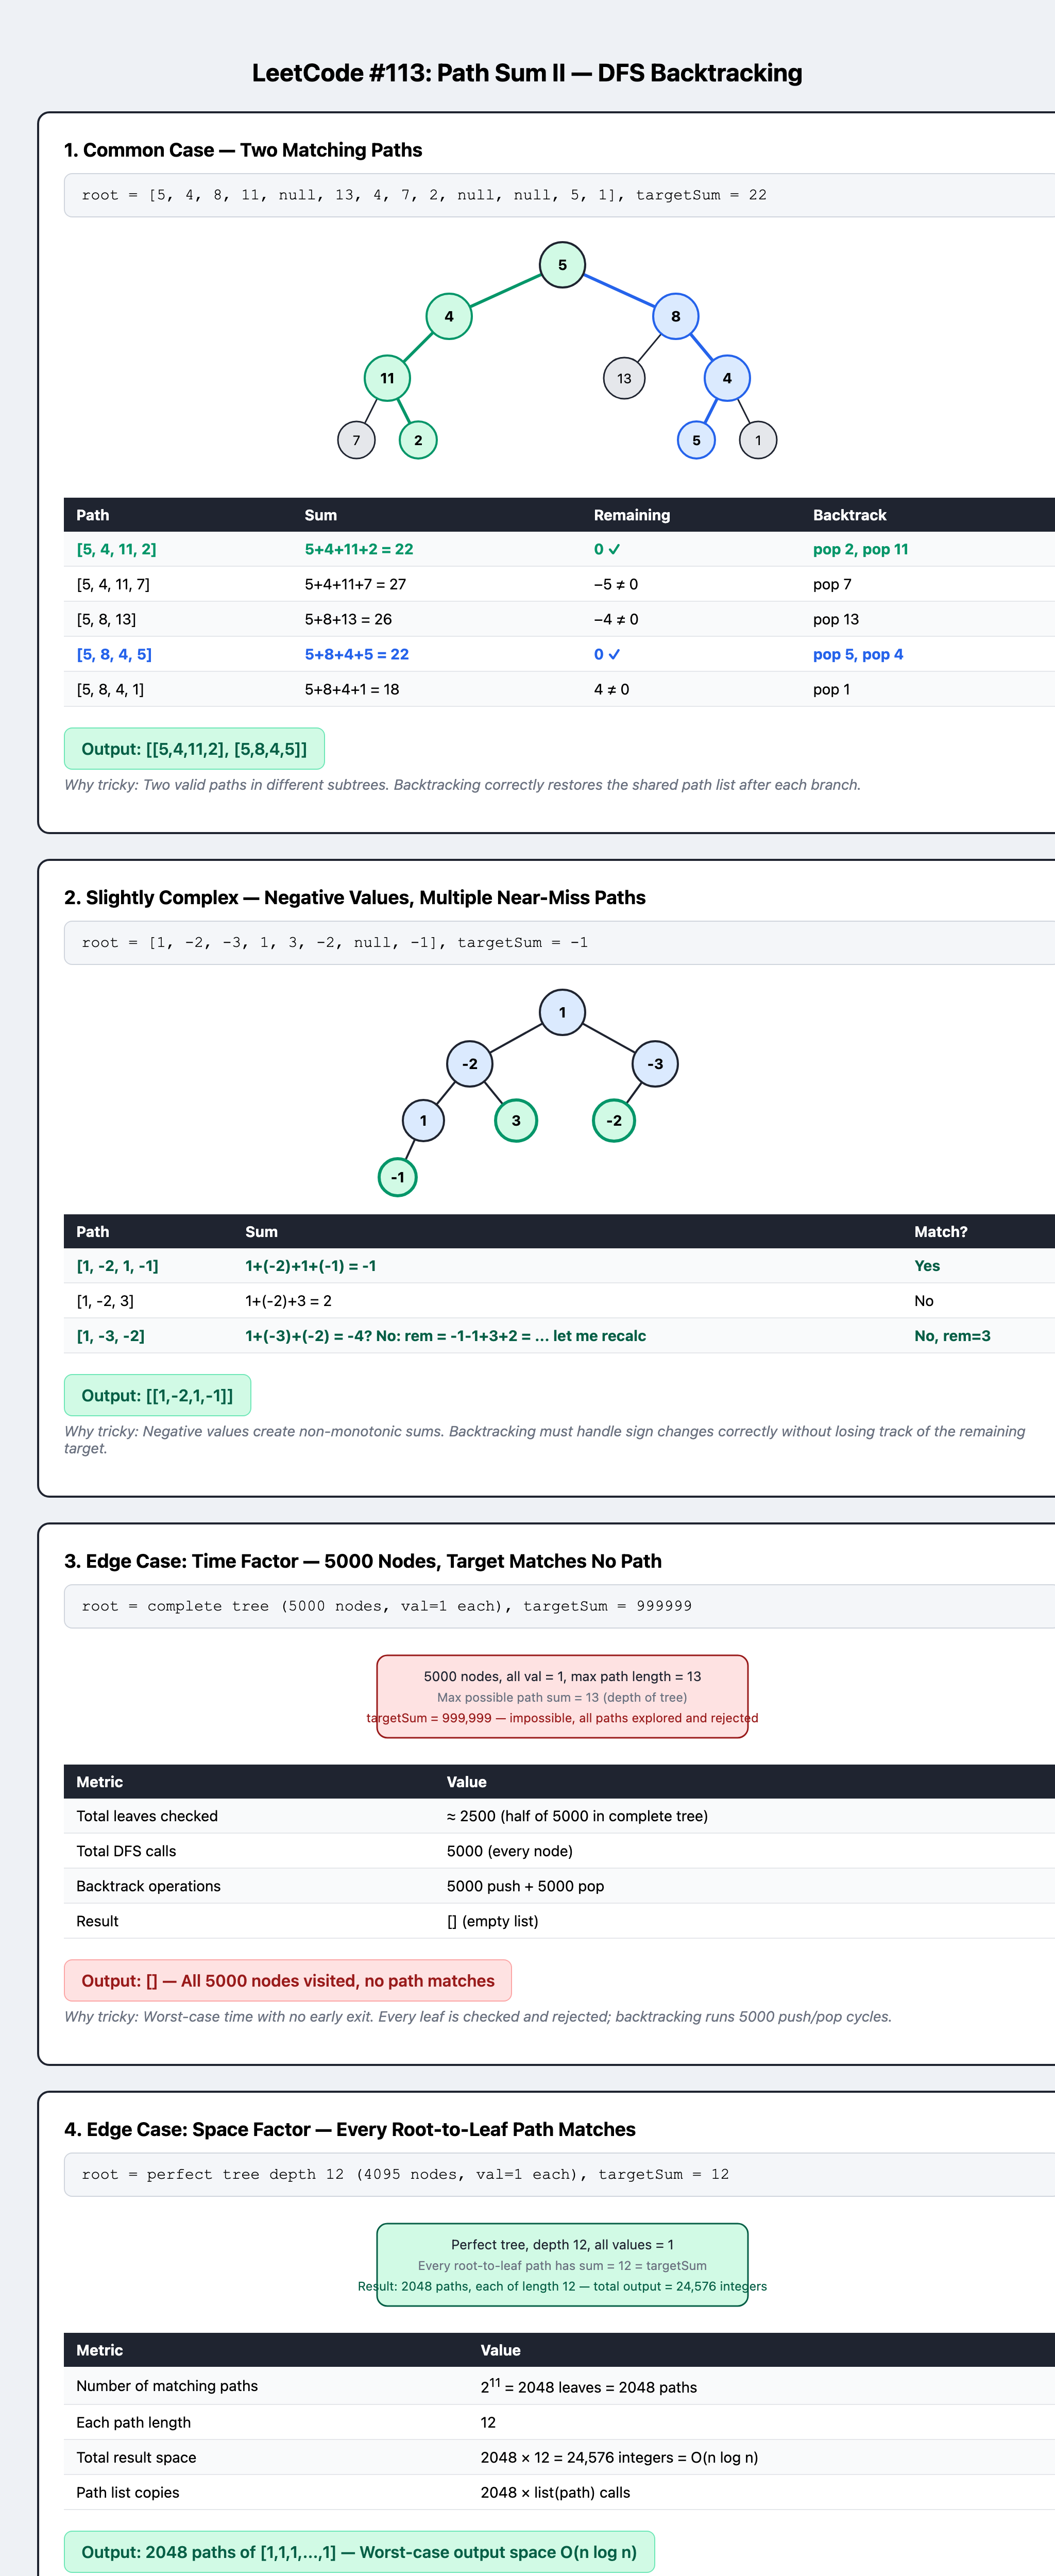